In [1]:
print('Running imports...')

import torch # long
import os
import numpy as np
import lightning as L
from torch.utils.data import DataLoader, TensorDataset, random_split
import xarray as xr
from models.model import Wang2024
from lightning.pytorch.loggers import WandbLogger
from lightning.pytorch import seed_everything
import wandb
from models.lightning import LitCNN_regression, AttributableTrainer, LogPlotsRegression
from models.losses import get_loss
import random
import matplotlib
from models.data import get_input_data, get_input_data_small,get_input_data_small_extended,get_input_data_small_extended_multidays
import pandas as pd
import cartopy.crs as ccrs
from models.attributions import log_attribution_regression
import argparse

Running imports...


In [2]:

def get_input_data_small_extended_multidays_LSTM(
        input_variable, region_predicted, type_prediction, batch_size,
        augment_train_set = False, n_days_predictant=1, n_days_predicted=1,
        include_gradients=True,
        lags=0):
    ds_in = xr.open_dataset('/Data/gfi/users/rogui7909/data/ERA5/dl_inputs_32x64.nc').data_normed.load().sel(var_name=input_variable)
    all_shifts = []
    for k in range(n_days_predictant):
        ds_shift = ds_in.shift(time=k)
        ds_shift = ds_shift.assign_coords(lag=f"lag{k}" )
        all_shifts.append(ds_shift)
    ds_shift = xr.concat(all_shifts[::-1], dim='lag')
    # if include_gradients:
    #     gradients = ds_shift.diff('lag').assign_coords(lag=[f"Grad{k+1}-{k}" for k in range(n_days_predictant-1)][::-1])
    #     ds_shift_grad = xr.concat([ds_shift, gradients], dim='lag')
    # else:
    #     ds_shift_grad = ds_shift
    ds_shift = ds_shift.transpose('time','lag','var_name','latitude','longitude')
    values_features = ds_shift.values
    tensor_in = torch.Tensor(values_features).type(torch.float32)

    with xr.open_dataarray('/Data/gfi/users/rogui7909/era5_rain_norge/ERA5land_daily_TP_indices.nc', chunks = dict(longitude=20, latitude=20, var_name=0)) as ds_out:
        data_out = ds_out.sel(mask_id=region_predicted)
        if type_prediction=='quantiles':
            data_out = (data_out.rank('time', pct=True)//.1).astype(int)
        all_out_shift = []
        for k in range(n_days_predicted):
            data_out_shift = data_out.shift(time=-k).assign_coords(lag=f"day+{k}")
            all_out_shift.append(data_out_shift)
        data_out_shifts = xr.concat(all_out_shift, dim='lag')
        data_out_values = data_out_shifts.values
    tensor_out = torch.Tensor(data_out_values).type(torch.float32).T

    tensor_in = tensor_in[n_days_predictant:-n_days_predicted]
    tensor_out = tensor_out[n_days_predictant:-n_days_predicted]
    if lags!=0:
        tensor_in = tensor_in[:-lags]
        tensor_out = tensor_out[lags:]
    dataset = TensorDataset(tensor_in, tensor_out)

    # use 20% of data for test
    trainvalid_set_size = int(len(dataset) * 0.8)
    test_set_size = len(dataset) - trainvalid_set_size
    # split the train set into two
    seed = torch.Generator().manual_seed(42)
    trainvalid_set, test_set = random_split(dataset, [trainvalid_set_size, test_set_size], generator=seed)

    # use 20% of training data for validation
    train_set_size = int(len(trainvalid_set) * 0.8)
    valid_set_size = len(trainvalid_set) - train_set_size

    # split the train set into two
    seed = torch.Generator().manual_seed(43)
    train_set, valid_set = random_split(trainvalid_set, [train_set_size, valid_set_size], generator=seed)
    # if augment_train_set:
    #     train_set = AugmentedRainfallDataset(train_set, threshold=30.0, noise_std=0.01, augment_factor=1)

    train_loader = DataLoader(train_set, batch_size=batch_size)
    valid_loader = DataLoader(valid_set, batch_size=batch_size)
    test_loader = DataLoader(test_set, batch_size=batch_size)

    ds_test = ds_shift.shift(time=lags).isel(time=test_loader.dataset.indices)

    return train_loader, valid_loader, test_loader, ds_test

In [3]:
attribute_test = False
wandb_logger = WandbLogger(project="Predict-rain-WNorway_multidays", 
                            save_dir="/Data/gfi/users/rogui7909/wanbd_logs/",
                            dir="/Data/gfi/users/rogui7909/wanbd_logs/wandb", )

# wandb_logger.experiment # Initialize wandb

# train_loader, valid_loader, test_loader, ds_test = get_input_data_small_extended(input_variable=wandb_logger.experiment.config['input_variable'], 
#                                                                                 region_predicted=14,
#                                                                                 type_prediction='regression', 
#                                                                                 batch_size=wandb_logger.experiment.config['batch_size'], 
#                                                                                 lags=wandb_logger.experiment.config['lags'], 
#                                                                                 augment_train_set=False)
train_loader, valid_loader, test_loader, ds_test = get_input_data_small_extended_multidays_LSTM(
                    input_variable=wandb_logger.experiment.config['input_variable'], 
                    region_predicted=14,
                    type_prediction='regression', 
                    batch_size=wandb_logger.experiment.config['batch_size'], 
                    lags=wandb_logger.experiment.config['lags'], 
                    augment_train_set=False,
                    n_days_predictant=wandb_logger.experiment.config['num_days_predictant'], 
                    n_days_predicted=wandb_logger.experiment.config['num_days_predicted'],
                    include_gradients=wandb_logger.experiment.config['include_gradient_features'],)

image_size = train_loader.dataset.dataset.dataset.tensors[0].shape[-1]*train_loader.dataset.dataset.dataset.tensors[0].shape[-2]

print('Data ready')

callbacks=[]

trainer = AttributableTrainer(limit_train_batches=100, max_epochs=wandb_logger.experiment.config['num_epochs'], 
                            logger=wandb_logger, 
                            log_every_n_steps=1, default_root_dir="/Data/gfi/users/rogui7909/lightning_checkpoint/",
                            callbacks=callbacks, deterministic=True,
                            accelerator="gpu", devices=1,
                            gradient_clip_val=wandb_logger.experiment.config['gradient_clip_val'])

num_classes = wandb_logger.experiment.config['num_days_predicted']
num_output_neurons = num_classes


wandb: Currently logged in as: rguilcas (rguilcas-university-of-bergen) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.


Data ready


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


In [23]:
ds =  xr.open_dataset('/Data/gfi/users/rogui7909/era5_rain_norge/era5_daily_rainfall_data_290125.nc').total_precipitation_day
ds_mask = xr.open_dataset('/Data/gfi/users/jodor4442/rainfall_regions/K39_ERA5land_lat_weighted_2d_direct.nc').tp
ds_mask = ds_mask.interp_like(ds, method='nearest')
# ds.isel(time=0).plot()
tp_per_region = ds.groupby(ds_mask).mean()



In [ ]:
quantiles=  tp_per_region.quantile(0.95, dim='time')
prediction = 1*(tp_per_region>quantiles)


<xarray.DataArray 'total_precipitation_day' (tp: 38)> Size: 304B
array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])
Coordinates:
    time      datetime64[ns] 8B 1959-01-21
    number    int64 8B 0
  * tp        (tp) float64 304B 1.0 3.0 4.0 5.0 6.0 ... 35.0 36.0 37.0 38.0 39.0
    quantile  float64 8B 0.95

In [4]:
from einops import rearrange
from torch import nn

class VisionTransformerRegressor(nn.Module):
    def __init__(self, image_size, patch_size, num_classes, num_channels_in, dim=128, depth=6, heads=8, mlp_dim=256, dropout=0.1):
        super().__init__()
        self.num_patches = (image_size // patch_size) ** 2
        self.patch_dim = num_channels_in * patch_size ** 2
        self.pos_embedding = nn.Parameter(torch.randn(1, self.num_patches + 1, dim))
        self.cls_token = nn.Parameter(torch.randn(1, 1, dim))
        self.patch_embed = nn.Linear(self.patch_dim, dim)
        self.transformer = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(d_model=dim, nhead=heads, dim_feedforward=mlp_dim, dropout=dropout),
            num_layers=depth
        )
        self.mlp_head = nn.Sequential(
            nn.LayerNorm(dim),
            nn.Linear(dim, num_classes)
        )
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        B, C, H, W = x.shape
        x = rearrange(x, 'b c (h p1) (w p2) -> b (h w) (p1 p2 c)', p1=H // (H // 16), p2=W // (W // 16))
        x = self.patch_embed(x)
        cls_tokens = self.cls_token.expand(B, -1, -1)
        x = torch.cat((cls_tokens, x), dim=1)
        x += self.pos_embedding[:, :x.shape[1], :]
        x = self.dropout(x)
        x = self.transformer(x)
        x = x[:, 0]
        x = self.mlp_head(x)
        return nn.functional.softplus(x)
    
import timm

class ConvNeXtRegressor(nn.Module):
    def __init__(self, num_classes=1, image_size=224, num_channels=3):
        super().__init__()
        self.image_size = image_size
        self.backbone = timm.create_model(
            "convnext_tiny",
            pretrained=False,
            features_only=False,
            in_chans=num_channels  # Ensure correct input channels
        )
        self.backbone.head.fc = nn.Linear(self.backbone.num_features, num_classes)
        self.activation = nn.Softplus()

    def forward(self, x):
        print(x.shape)
        assert x.shape[-2:] == (self.image_size, self.image_size), \
            f"Expected input size {(self.image_size, self.image_size)}, but got {x.shape[-2:]}"
        x = self.backbone(x)
        return self.activation(x)

In [5]:
from torch import nn
class CNN_LSTM_Model(nn.Module):
    def __init__(self, input_channels, hidden_size, output_size):
        super(CNN_LSTM_Model, self).__init__()
        
        # CNN layers to extract spatial features
        self.cnn = nn.Sequential(
            nn.Conv2d(input_channels, 64, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )
        
        # LSTM layer to capture temporal dependencies
        self.lstm = nn.LSTM(input_size=128*8*8*2, hidden_size=hidden_size, batch_first=True)
        
        # Fully connected layer for final prediction
        self.fc = nn.Linear(hidden_size, output_size)
    
    def forward(self, x):
        # x shape: (batch_size, seq_length, channels, height, width)
        # Apply CNN to extract spatial features
        batch_size, seq_length, channels, height, width = x.size()
        cnn_out = []
        for i in range(seq_length):
            cnn_out.append(self.cnn(x[:, i, :, :, :]))  # Extract features from each time step
        cnn_out = torch.stack(cnn_out, dim=1)  # Shape: (batch_size, seq_length, channels, height, width)
        # Flatten CNN output for LSTM
        cnn_out = cnn_out.view(batch_size, seq_length, -1)  # Shape: (batch_size, seq_length, features)
        # Apply LSTM
        lstm_out, _ = self.lstm(cnn_out)
        
        # Get last time step output and pass through fully connected layer
        lstm_out = lstm_out[:, -1, :]  # Shape: (batch_size, hidden_size)
        output = self.fc(lstm_out)  # Shape: (batch_size, output_size)
        return output

In [6]:
CNN = CNN_LSTM_Model(input_channels=len(wandb_logger.experiment.config['input_variable']),
                 hidden_size=256,
                 output_size = wandb_logger.experiment.config['num_days_predicted']
                 )



loss = get_loss(wandb_logger.experiment.config['loss_fn'])


model = LitCNN_regression(CNN, 
                        learning_rate=wandb_logger.experiment.config['learning_rate'], 
                        loss_fn = loss)

print('Model init')
trainer.fit(model, train_loader, valid_loader)

model.eval()
with torch.no_grad():
    trainer.test(model, dataloaders=test_loader)


Model init


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]

  | Name    | Type              | Params | Mode 
------------------------------------------------------
0 | model   | CNN_LSTM_Model    | 17.1 M | train
1 | loss_fn | AsymmetricMSELoss | 0      | train
------------------------------------------------------
17.1 M    Trainable params
0         Non-trainable params
17.1 M    Total params
68.479    Total estimated model params size (MB)
11        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/felles_gfi/felles_gfi_users/rogui7909/miniforge3/envs/robin/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=71` in the `DataLoader` to improve performance.
/felles_gfi/felles_gfi_users/rogui7909/miniforge3/envs/robin/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=71` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=10` reached.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
/felles_gfi/felles_gfi_users/rogui7909/miniforge3/envs/robin/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=71` in the `DataLoader` to improve performance.


Testing: |          | 0/? [00:00<?, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test/loss            79.88874053955078
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


In [19]:
truth

[tensor([0.9140, 4.9025, 0.2298], device='cuda:0'),
 tensor([0.2694, 0.1308, 0.0517], device='cuda:0'),
 tensor([ 0.5218,  6.4903, 12.1584], device='cuda:0'),
 tensor([5.1343, 5.3359, 2.8392], device='cuda:0'),
 tensor([24.2478, 13.8655,  5.1343], device='cuda:0'),
 tensor([2.0779, 0.4968, 5.0877], device='cuda:0'),
 tensor([0.1763, 2.4848, 5.4114], device='cuda:0'),
 tensor([11.7318,  9.6332,  4.0866], device='cuda:0'),
 tensor([ 2.2200,  1.2455, 12.4852], device='cuda:0'),
 tensor([ 6.5800,  1.3505, 11.1096], device='cuda:0'),
 tensor([1.0057, 5.0055, 6.5669], device='cuda:0'),
 tensor([ 1.9464, 16.2095,  5.2756], device='cuda:0'),
 tensor([0.5863, 4.5046, 6.7082], device='cuda:0'),
 tensor([9.9444, 5.8532, 2.1477], device='cuda:0'),
 tensor([10.1313,  4.8271,  2.7434], device='cuda:0'),
 tensor([ 8.2209, 45.5027, 17.0468], device='cuda:0'),
 tensor([1.9874, 0.7080, 6.0578], device='cuda:0'),
 tensor([1.3223, 0.7495, 2.7892], device='cuda:0'),
 tensor([20.4821, 11.0985,  6.5813], dev

In [ ]:
min_rain = 21
from captum.attr import IntegratedGradients

truth = torch.stack(model.test_true_values).cpu().numpy()
pred = torch.stack(model.test_pred).cpu().numpy()
true_indices = np.where((truth[:,2]>=min_rain)&(pred[:,2]>=min_rain))[0]
data_in_true_target = torch.cat([batch[0] for batch in test_loader])[true_indices]
data_out_true_target = torch.Tensor(pred[true_indices])
dataset_attr = TensorDataset(data_in_true_target,data_out_true_target)
attribution_loader = DataLoader(dataset_attr, batch_size=10)

baseline = torch.stack([torch.cat([torch.zeros_like(batch[0]) for batch in test_loader]).mean(dim=0)])
ig = IntegratedGradients(model.model)
# dl = DeepLift(model.model)

attribution_ig = trainer.attribute(attribution_loader, baselines=baseline, target=2, attribution_method=ig)
# attribution_nt = self.attribute(attribution_loader, baselines=baseline, target=0, attribution_method=nt)
# attribution_dl = self.attribute(attribution_loader, baselines=baseline, target=0, attribution_method=dl)

attribution_da = xr.DataArray([attribution_ig], 
                            dims=['attr_method']+list(ds_test.dims), 
                            coords={'attr_method':['IntegratedGradients', 
                                                #    'IntegratedGradients+NoiseTunnel'
                                                    ], 
                                    **ds_test.isel(time=true_indices).coords})
pred_da = xr.DataArray(pred[true_indices,2], dims=['time'], coords=dict(time=attribution_da.time))
truth_da = xr.DataArray(truth[true_indices,2], dims=['time'], coords=dict(time=attribution_da.time))

ds_attr = xr.Dataset(dict(data = ds_test.isel(time=true_indices)-ds_test.mean('time'),
                            attributions = attribution_da,
                            pred=pred_da, truth = truth_da)).sortby('time').assign_coords(min_rain=min_rain)
ds_attr.attrs['baseline_prediction'] = model(baseline).detach().numpy().squeeze()

Computing Attributions: 100%|██████████| 3/3 [00:23<00:00,  7.70s/it]


ValueError: different number of dimensions on data and dims: 2 vs 1

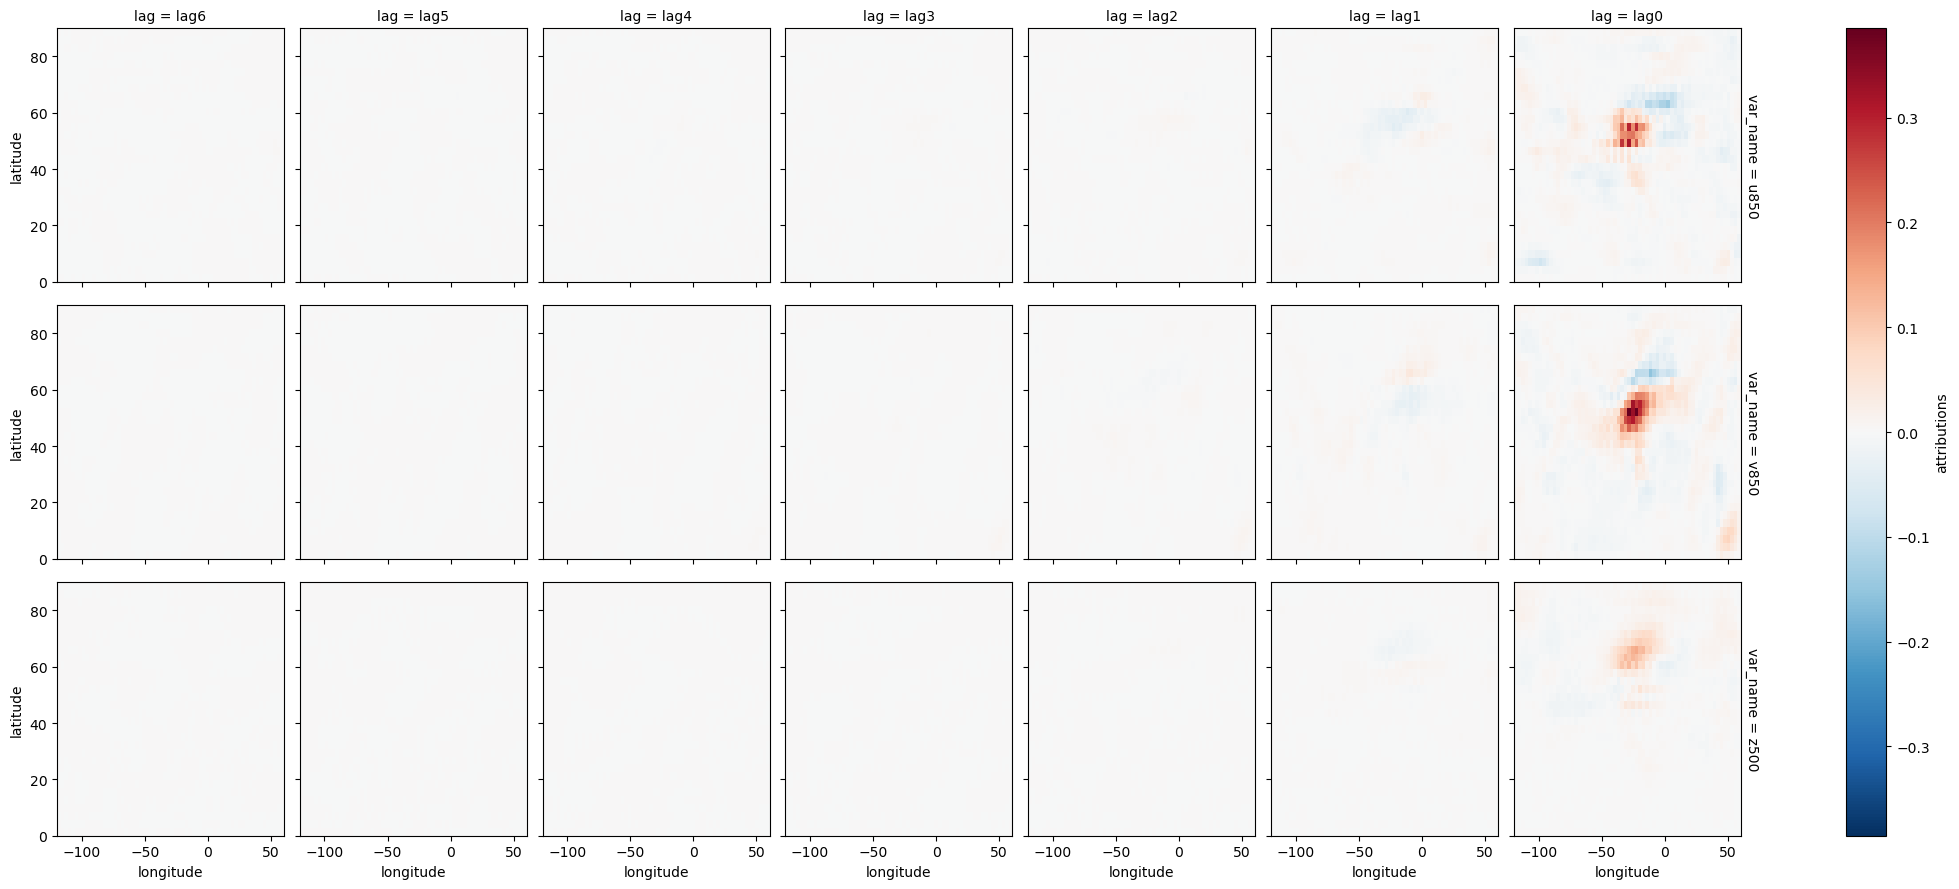

In [25]:
ds_attr.mean('time').attributions.plot(col='lag',row='var_name')

In [7]:
truth = torch.stack(model.test_true_values).cpu().numpy()
pred = torch.stack(model.test_pred).cpu().numpy()
import matplotlib.pyplot as plt
# df = pd.DataFrame(dict(truth=truth.squeeze(), pred=pred.squeeze()))
# df.corr()
df_truth = pd.DataFrame(truth, columns = [f"truth_lag{k}" for k in range(truth.shape[1])])
df_pred = pd.DataFrame(pred, columns = [f"pred_lag{k}" for k in range(pred.shape[1])])
df = pd.concat([df_truth, df_pred], axis=1)

In [10]:
df.corr()

,truth_lag0,truth_lag1,truth_lag2,truth_lag3,truth_lag4,truth_lag5,truth_lag6,truth_lag7,truth_lag8,truth_lag9,pred_lag0,pred_lag1,pred_lag2,pred_lag3,pred_lag4,pred_lag5,pred_lag6,pred_lag7,pred_lag8,pred_lag9
truth_lag0,1.000000,0.500265,0.287458,0.214806,0.172555,0.146561,0.139476,0.121392,0.126486,0.099623,0.526953,0.525154,0.515986,0.512131,0.505943,0.503100,0.499057,0.496210,0.500064,0.491558
truth_lag1,0.500265,1.000000,0.488671,0.296970,0.230410,0.197235,0.161469,0.108815,0.119821,0.121709,0.487861,0.489671,0.479938,0.475793,0.465906,0.460858,0.454809,0.452054,0.452144,0.446318
truth_lag2,0.287458,0.488671,1.000000,0.512242,0.303029,0.234840,0.197529,0.149474,0.142941,0.162266,0.389241,0.390847,0.385185,0.382951,0.374952,0.369732,0.366813,0.363162,0.360356,0.355545
truth_lag3,0.214806,0.296970,0.512242,1.000000,0.501422,0.282202,0.229520,0.177069,0.160718,0.156603,0.306798,0.308045,0.305355,0.304011,0.299781,0.297316,0.295363,0.290092,0.288153,0.287274
truth_lag4,0.172555,0.230410,0.303029,0.501422,1.000000,0.494608,0.291377,0.217463,0.195015,0.178182,0.266308,0.267982,0.266914,0.266892,0.265519,0.263518,0.262246,0.258416,0.258047,0.255750
truth_lag5,0.146561,0.197235,0.234840,0.282202,0.494608,1.000000,0.497795,0.269017,0.243721,0.213375,0.229285,0.231321,0.230761,0.229578,0.228786,0.227135,0.225386,0.223987,0.223644,0.217300
truth_lag6,0.139476,0.161469,0.197529,0.229520,0.291377,0.497795,1.000000,0.509687,0.311639,0.266496,0.215850,0.217059,0.217402,0.215453,0.215306,0.215294,0.213539,0.213317,0.213407,0.209430
truth_lag7,0.121392,0.108815,0.149474,0.177069,0.217463,0.269017,0.509687,1.000000,0.494893,0.280833,0.185287,0.186532,0.185724,0.185568,0.183008,0.183743,0.181316,0.179376,0.180264,0.179311
truth_lag8,0.126486,0.119821,0.142941,0.160718,0.195015,0.243721,0.311639,0.494893,1.000000,0.498293,0.180365,0.181288,0.181693,0.180827,0.178506,0.177268,0.176438,0.175318,0.175960,0.171711
truth_lag9,0.099623,0.121709,0.162266,0.156603,0.178182,0.213375,0.266496,0.280833,0.498293,1.000000,0.165228,0.165896,0.165763,0.166592,0.161986,0.162644,0.161106,0.161816,0.161219,0.161184


In [7]:
min_rain = 0
from captum.attr import IntegratedGradients

truth = torch.stack(model.test_true_values).cpu().numpy()
pred = torch.stack(model.test_pred).cpu().numpy()

# true_indices = np.where((truth>=min_rain)&(pred>=min_rain))[0]
# data_in_true_target = torch.cat([batch[0] for batch in test_loader])[true_indices]
# data_out_true_target = torch.Tensor(pred[true_indices])
# dataset_attr = TensorDataset(data_in_true_target,data_out_true_target)
# attribution_loader = DataLoader(dataset_attr, batch_size=10)
attribution_loader = test_loader
baseline = torch.stack([torch.cat([torch.zeros_like(batch[0]) for batch in test_loader]).mean(dim=0)])
ig = IntegratedGradients(trainer.model.model)
# dl = DeepLift(trainer.model.model)
all_attr = []
for target_day in range(wandb_logger.experiment.config['num_days_predicted']):
    attribution_ig = trainer.attribute(attribution_loader, baselines=baseline, target=target_day, attribution_method=ig)
    # attribution_nt = trainer.attribute(attribution_loader, baselines=baseline, target=0, attribution_method=nt)
    # attribution_dl = trainer.attribute(attribution_loader, baselines=baseline, target=0, attribution_method=dl)

    attribution_da = xr.DataArray([attribution_ig], 
                                dims=['attr_method']+list(ds_test.dims), 
                                coords={'attr_method':['IntegratedGradients', 
                                                    #    'IntegratedGradients+NoiseTunnel'
                                                        ], 
                                        **ds_test.coords})
    pred_da = xr.DataArray(pred[:,target_day], dims=['time'], coords=dict(time=attribution_da.time))
    truth_da = xr.DataArray(truth[:,target_day], dims=['time'], coords=dict(time=attribution_da.time))

    ds_attr = xr.Dataset(dict(data = ds_test-ds_test.mean('time'),
                                attributions = attribution_da,
                                pred=pred_da, truth = truth_da))#.sortby('time').assign_coords(min_rain=min_rain)
    all_attr.append(ds_attr.assign_coords(target_day=target_day))
ds = xr.concat(all_attr, dim='target_day')
# ds_attr.attrs['baseline_prediction'] = trainer.model(baseline).detach().numpy().squeeze()

Computing Attributions:   0%|          | 0/9 [00:00<?, ?it/s]

torch.Size([25600, 256])
torch.Size([25600, 1])


Computing Attributions:  11%|█         | 1/9 [02:17<18:20, 137.53s/it]

torch.Size([25600, 256])
torch.Size([25600, 1])


Computing Attributions:  22%|██▏       | 2/9 [04:31<15:49, 135.66s/it]

...

Computing Attributions:  78%|███████▊  | 7/9 [15:57<04:34, 137.47s/it]

torch.Size([25600, 256])
torch.Size([25600, 1])


Computing Attributions:  89%|████████▉ | 8/9 [18:23<02:20, 140.13s/it]

torch.Size([25300, 256])
torch.Size([25300, 1])


Computing Attributions: 100%|██████████| 9/9 [20:33<00:00, 137.06s/it]


In [11]:
ds_over20 = ds.where((ds.pred>20)&(ds.truth>20), drop=True)

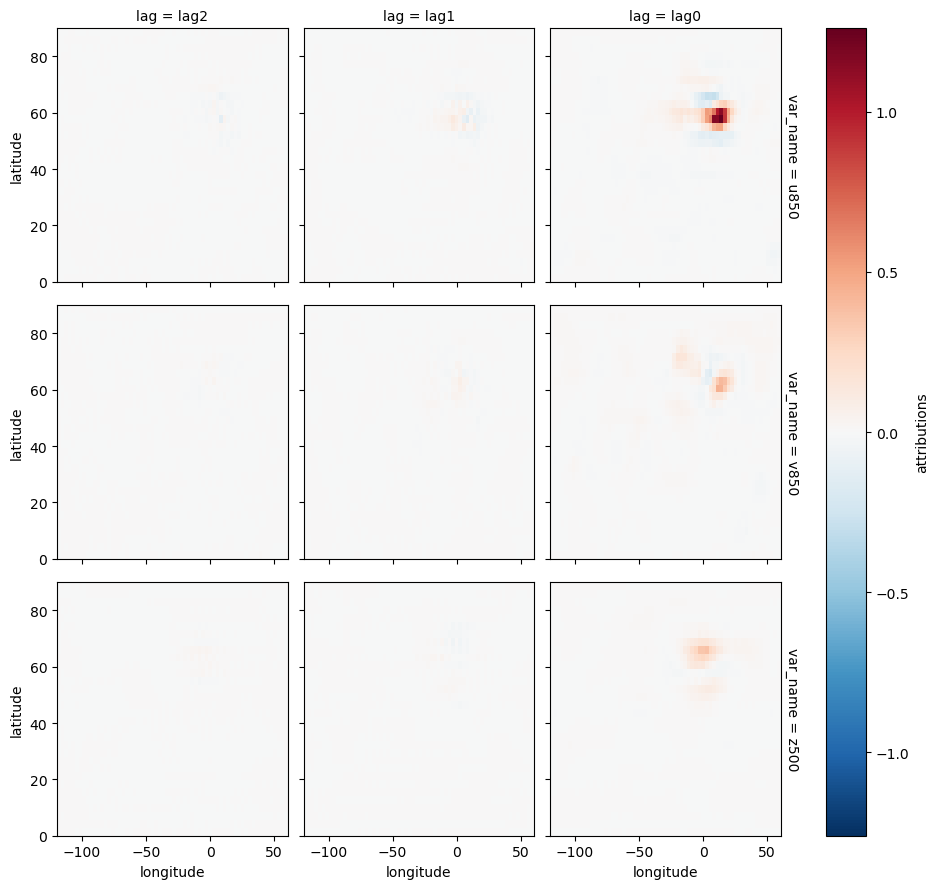

In [15]:
ds_over20.mean('time').attributions.plot(col='lag', row='var_name')

In [ ]:

    viT = VisionTransformerRegressor(
                num_classes=num_output_neurons, 
                num_channels_in=ds_test.features.size, 
                patch_size = patch_size=16
                image_size=image_size, 
                groups=len(len(wandb_logger.experiment.config['input_variable']),
                size_conv1_kernel=wandb_logger.experiment.config['conv1_kernel_size'],
                size_conv2_kernel=wandb_logger.experiment.config['conv2_kernel_size'],
                out_channels_conv1=wandb_logger.experiment.config['conv1_kernel_number'],
                out_channels_conv2=wandb_logger.experiment.config['conv2_kernel_number'],
                dropout_proba=wandb_logger.experiment.config['dropout_proba'],)


    loss = get_loss(wandb_logger.experiment.config['loss_fn'])


    model = LitCNN_regression(CNN, 
                            learning_rate=wandb_logger.experiment.config['learning_rate'], 
                            loss_fn = loss)

    print('Model init')
    trainer.fit(model, train_loader, valid_loader)


    model.eval()
    with torch.no_grad():
        trainer.test(model, dataloaders=test_loader)

/felles_gfi/felles_gfi_users/rogui7909/miniforge3/envs/robin/lib/python3.12/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:654: Checkpoint directory /Data/gfi/users/rogui7909/wanbd_logs/Predict-rain-WNorway_multidays/bhhrhxxq/checkpoints exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]

  | Name    | Type              | Params | Mode 
------------------------------------------------------
0 | model   | ConvNeXtRegressor | 27.8 M | train
1 | loss_fn | MSELoss           | 0      | train
------------------------------------------------------
27.8 M    Trainable params
0         Non-trainable params
27.8 M    Total params
111.357   Total estimated model params size (MB)
252       Modules in train mode
0         Modules in eval mode


Model init


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

torch.Size([512, 15, 32, 64])


/felles_gfi/felles_gfi_users/rogui7909/miniforge3/envs/robin/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=71` in the `DataLoader` to improve performance.


AssertionError: Expected input size (2048, 2048), but got torch.Size([32, 64])

In [19]:
truth

NameError: name 'truth' is not defined

wandb: 
wandb: 🚀 View run electric-puddle-16 at: https://wandb.ai/rguilcas-university-of-bergen/Predict-rain-WNorway_multidays/runs/d6ukjn9l
wandb: Find logs at: ../../../../../../Data/gfi/users/rogui7909/wanbd_logs/wandb/run-20250317_153637-d6ukjn9l/logs
